<a href="https://colab.research.google.com/github/Nikil-Abbishak/Loan-Approval-ML-prediction/blob/main/ML_Notebook_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook 3: Ensemble Learning and Regression Modelling

Author: Nikil Abbishak  
Peer Reviewer: Nethmi Divakara  



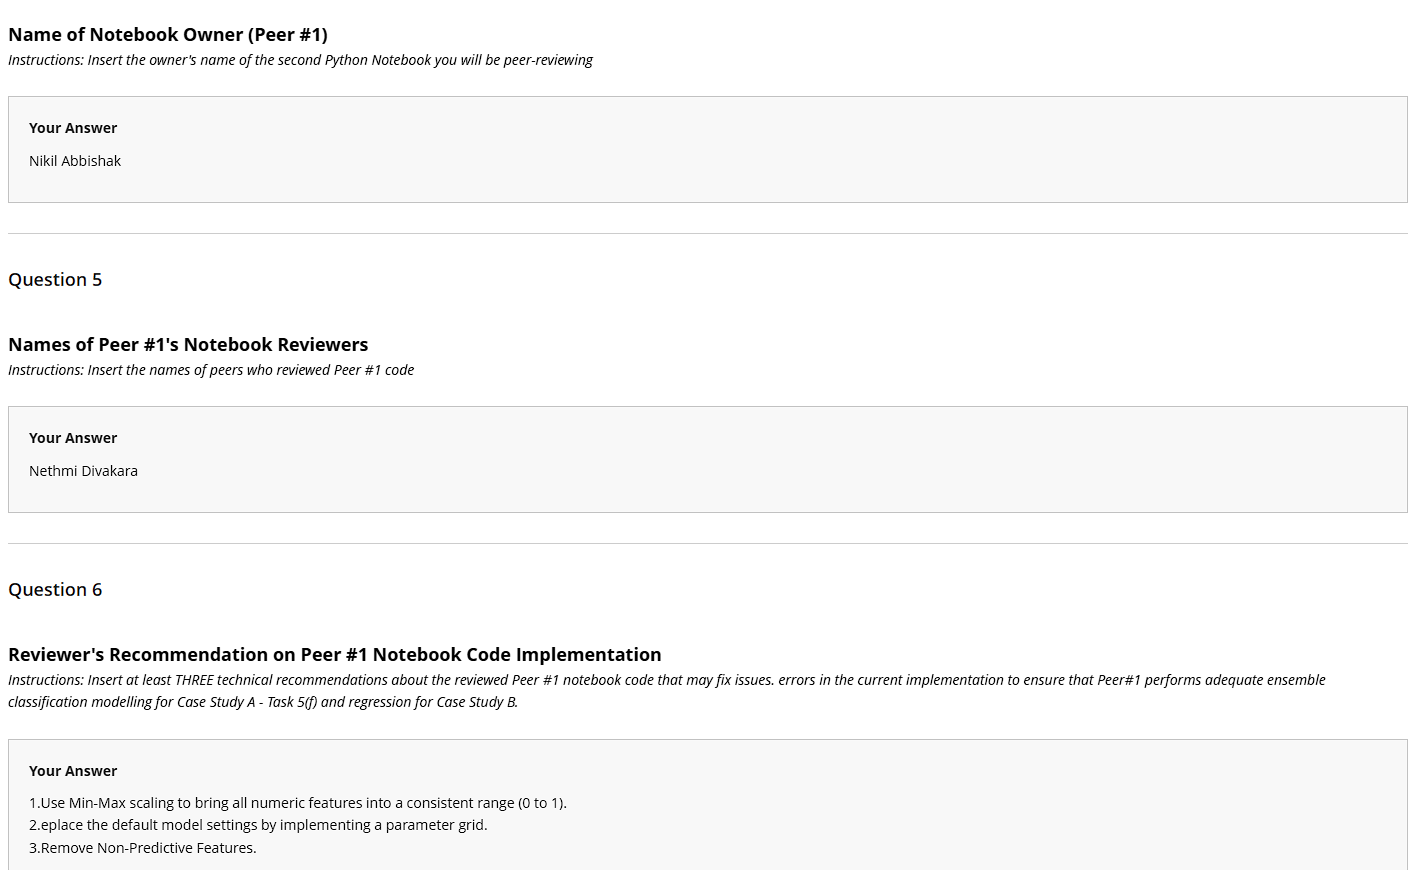

Section 1 - Import Libraries  
Leveraged from Coursework Code Reuse Session 3 / Tutorial 7.

In [ ]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import the function used to split data into training and test sets
from sklearn.model_selection import train_test_split

# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Import Logistic Regression as a base learner
from sklearn.linear_model import LogisticRegression

# Import K-Nearest Neighbours as a base learner
from sklearn.neighbors import KNeighborsClassifier

# Import the VotingClassifier to build the ensemble learner
from sklearn.ensemble import VotingClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

Section 2 - Load Dataset  
Leveraged from Notebook 1 output.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/classification_dataset.csv')

df.head()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,0,-2426900,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,0,-111739,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,0,-89000,False,False,True,False,False,True,False,False,False
3,40.0,182004,3,35000,8.00,0.19,11,0,35000,False,False,True,True,False,False,False,False,False
4,40.0,90000,3,35000,12.42,0.39,14,0,35000,False,False,False,False,True,False,False,False,False


Section 3 - Define Input Features and Target Variable

Leveraged and reused from: Coursework Code Reuse Session 2 / reused in Coursework Code Reuse Session 3.


In [ ]:
# Define the input features by dropping the target column
X = df.drop(['loan_approval_status','max_allowed_loan'], axis=1)

# Define the target variable
y = df['loan_approval_status']

# Display the input feature names
list(X.columns)

['age',
 'income',
 'emplyment_length',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'credit_history_length',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'payment_default_on_file_Y']

In [ ]:
# Display the shapes of the input matrix and target vector
X.shape, y.shape

((58644, 16), (58644,))

Section 4 - Training and Test Split

Leveraged and reused from: Coursework Code Reuse Session 2 / Tutorial 3 / reused in Notebook 3.

In [ ]:
# Split the data into training and test sets using stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes of the training and test sets
X_train.shape, X_test.shape

((46915, 16), (11729, 16))

Section 5 - Feature Scaling

Leveraged and reused from:** Coursework Code Reuse Session 2 / Tutorial 3 / reused in Notebook 3 for ensemble base learners.

In [ ]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training features
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test features using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

Section 6 - Build Base Learners

Leveraged and reused from: Coursework Code Reuse Session 2 / Coursework Code Reuse Session 3 / Tutorial 4 / Tutorial 7.


In [ ]:
# Declare base learners using tuned KNN
lr = LogisticRegression(max_iter=1000)

knn = KNeighborsClassifier(n_neighbors=5) #tuned KNN n_neighbors value in notebook 2

# Create ensemble
ensemble_learner = VotingClassifier(
    estimators=[('LR', lr), ('KNN', knn)],
    voting='soft'
)

# Fit ensemble
ensemble_learner.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('LR', LogisticRegression(max_iter=1000)),
                             ('KNN', KNeighborsClassifier())],
                 voting='soft')

Section 7 - Evaluate the Logistic Regression Base Learner

Leveraged and reused from: Coursework Code Reuse Session 2 / reused in Coursework Code Reuse Session 3.

In [ ]:
# Fit the Logistic Regression model before evaluation
lr.fit(X_train_scaled, y_train)

# Generate predictions from the Logistic Regression model
y_pred_lr = lr.predict(X_test_scaled)

# Calculate and display the accuracy of the Logistic Regression model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# Display the classification report for the Logistic Regression model
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8959843123880978
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10059
           1       0.73      0.43      0.54      1670

    accuracy                           0.90     11729
   macro avg       0.82      0.70      0.74     11729
weighted avg       0.89      0.90      0.88     11729



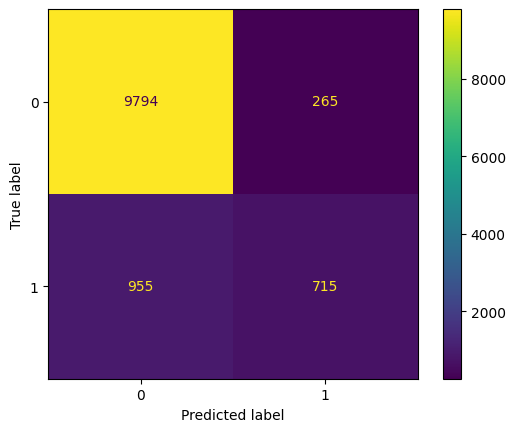

In [ ]:
# Construct the confusion matrix for the Logistic Regression model
lr_cm = confusion_matrix(y_test, y_pred_lr, labels=lr.classes_)

# Display the confusion matrix for the Logistic Regression model
lr_disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm, display_labels=lr.classes_)
lr_disp.plot()

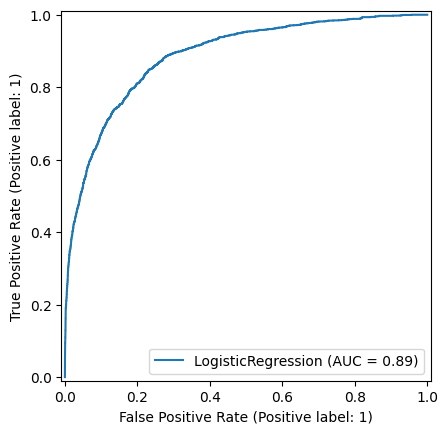

In [ ]:
# Plot the ROC curve for the Logistic Regression model
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)

Section 8 - Evaluate the KNN Base Learner

Leveraged and reused from: Coursework Code Reuse Session 2 / reused in Coursework Code Reuse Session 3.

In [ ]:
# Fit the KNN model before generating predictions
knn.fit(X_train_scaled, y_train)

# Generate predictions from the KNN model
y_pred_knn = knn.predict(X_test_scaled)

# Calculate and display the accuracy of the KNN model
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# Display the classification report for the KNN model
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9188336601585813
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10059
           1       0.82      0.56      0.66      1670

    accuracy                           0.92     11729
   macro avg       0.87      0.77      0.81     11729
weighted avg       0.91      0.92      0.91     11729



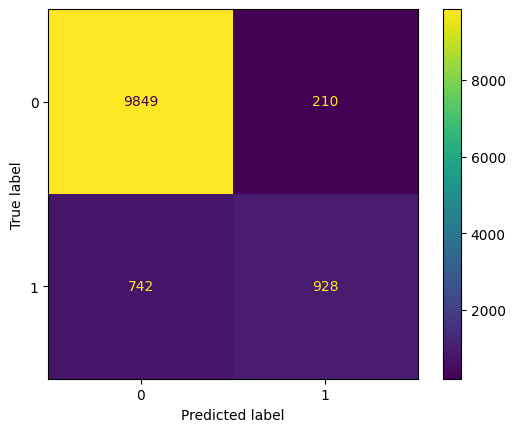

In [ ]:
# Construct the confusion matrix for the tuned KNN model
knn_cm = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)

# Display the confusion matrix for the tuned KNN model
knn_disp = ConfusionMatrixDisplay(confusion_matrix=knn_cm, display_labels=knn.classes_)
knn_disp.plot()

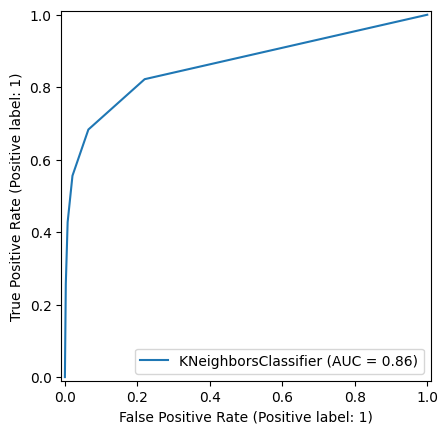

In [ ]:
# Plot the ROC curve for the KNN model
RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test)

Section 9 - Build the Soft Voting Ensemble Classifier

Leveraged and reused from: Coursework Code Reuse Session 3 / Tutorial 7.

In [ ]:
# Create the soft voting ensemble classifier
ensemble_learner = VotingClassifier(
    estimators=[('LR', lr), ('KNN', knn)],
    voting='soft'
)

# Train the ensemble classifier on the scaled training data
ensemble_learner.fit(X_train_scaled, y_train)

# Generate predictions from the ensemble classifier
y_pred_ensemble = ensemble_learner.predict(X_test_scaled)

Section 10 - Evaluate the Soft Voting Ensemble Classifier

Leveraged and reused from: Coursework Code Reuse Session 3 / Tutorial 7.

In [ ]:
# Calculate and display the accuracy of the ensemble classifier
print("Ensemble Classifier Accuracy:", accuracy_score(y_test, y_pred_ensemble))

# Display the classification report for the ensemble classifier
print(classification_report(y_test, y_pred_ensemble))

Ensemble Classifier Accuracy: 0.9196862477619575
              precision    recall  f1-score   support

           0       0.93      0.99      0.95     10059
           1       0.86      0.52      0.65      1670

    accuracy                           0.92     11729
   macro avg       0.89      0.75      0.80     11729
weighted avg       0.92      0.92      0.91     11729



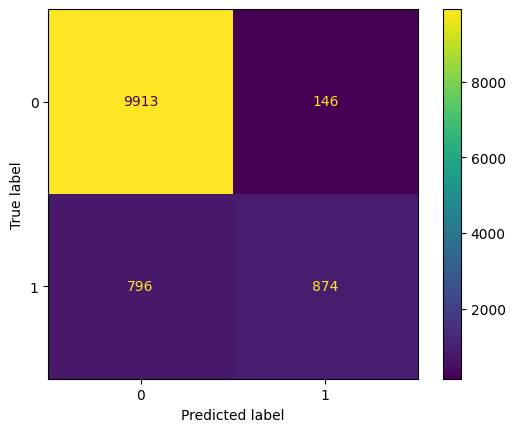

In [ ]:
# Construct the confusion matrix for the ensemble classifier
ensemble_cm = confusion_matrix(y_test, y_pred_ensemble, labels=ensemble_learner.classes_)

# Display the confusion matrix for the ensemble classifier
ensemble_disp = ConfusionMatrixDisplay(confusion_matrix=ensemble_cm, display_labels=ensemble_learner.classes_)
ensemble_disp.plot()

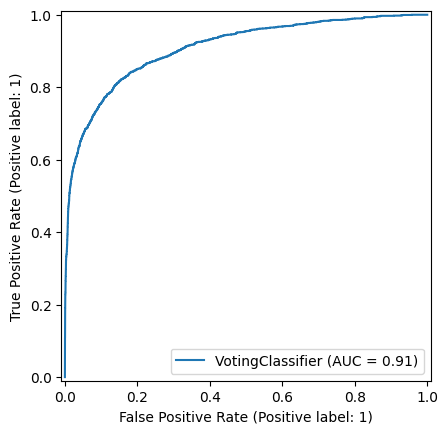

In [ ]:
# Plot the ROC curve for the ensemble classifier
RocCurveDisplay.from_estimator(ensemble_learner, X_test_scaled, y_test)

Section 11 - Summary of Ensemble Classification Results

Leveraged and reused from: Coursework Code Reuse Session 3 / Tutorial 7.

In [ ]:
# Create a summary table comparing model accuracies
ensemble_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Soft Voting Ensemble'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_ensemble)
    ]
})

# Display the summary table
ensemble_results

,Model,Accuracy
0,Logistic Regression,0.895984
1,KNN,0.918834
2,Soft Voting Ensemble,0.919686


Section 12 - Load Regression Dataset  

Leveraged and reused from: Notebook 1 output / Coursework Code Reuse Session 3 / Tutorial 6.

In [ ]:
# Load the regression dataset created in Notebook 1
df_reg = pd.read_csv('/content/drive/MyDrive/regression_dataset.csv')

# Display the first few rows
df_reg.head()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,max_allowed_loan,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,-2426900,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,-111739,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,-89000,False,False,True,False,False,True,False,False,False
3,40.0,182004,3,35000,8.00,0.19,11,35000,False,False,True,True,False,False,False,False,False
4,40.0,90000,3,35000,12.42,0.39,14,35000,False,False,False,False,True,False,False,False,False


Section 13 - Define Input Features and Target Variable  

Leveraged and reused from: Coursework Code Reuse Session 3 / Tutorial 6.  

In [ ]:
# Define input features by dropping the target column
X = df_reg.drop('max_allowed_loan', axis=1)

# Define target variable
y = df_reg['max_allowed_loan']

# Display shapes
X.shape, y.shape

((50294, 16), (50294,))

Section 14 - Training and Test Split  

Leveraged and reused from: Coursework Code Reuse Session 2 / reused in Session 3.  


In [ ]:
# Split the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display shapes
X_train.shape, X_test.shape

((40235, 16), (10059, 16))

Section 15 - Import Decision Tree Regressor  

Leveraged and reused from: Coursework Code Reuse Session 3 / Tutorial 6.

In [ ]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

Section 16 - Fully Grown Decision Tree  

Leveraged and reused from: Coursework Code Reuse Session 3 / Tutorial 6.  

In [ ]:
# Create fully grown decision tree
dt_full = DecisionTreeRegressor(random_state=42)

# Train model
dt_full.fit(X_train, y_train)

# Predictions
y_pred_full = dt_full.predict(X_test)

Section 17 - Pruned Decision Tree (Max Depth = 4)  

Leveraged and reused from: Coursework Code Reuse Session 3 / Tutorial 6.  

In [ ]:
# Create pruned decision tree
dt_pruned = DecisionTreeRegressor(max_depth=4, random_state=42)

# Train model
dt_pruned.fit(X_train, y_train)

# Predictions
y_pred_pruned = dt_pruned.predict(X_test)

Section 18 - Regression Model Evaluation  

Leveraged and reused from: Coursework Code Reuse Session 3 / Tutorial 6.  

In [ ]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Evaluation function
def evaluate_model(y_test, y_pred, model_name):

    print(f"\n{model_name}")

    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))

In [ ]:
# Evaluate full tree
evaluate_model(y_test, y_pred_full, "Fully Grown Tree")

# Evaluate pruned tree
evaluate_model(y_test, y_pred_pruned, "Pruned Tree")


Fully Grown Tree
MAE: 1385.6776021473308
MSE: 137530153.5642708
R2 Score: 0.9543691774562539

Pruned Tree
MAE: 12073.950593134847
MSE: 444009633.23923916
R2 Score: 0.8526830352691689


Section 19 - Visualising Decision Trees  

Leveraged and reused from: Coursework Code Reuse Session 3 / Tutorial 6.  

In [ ]:
# Import plot_tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

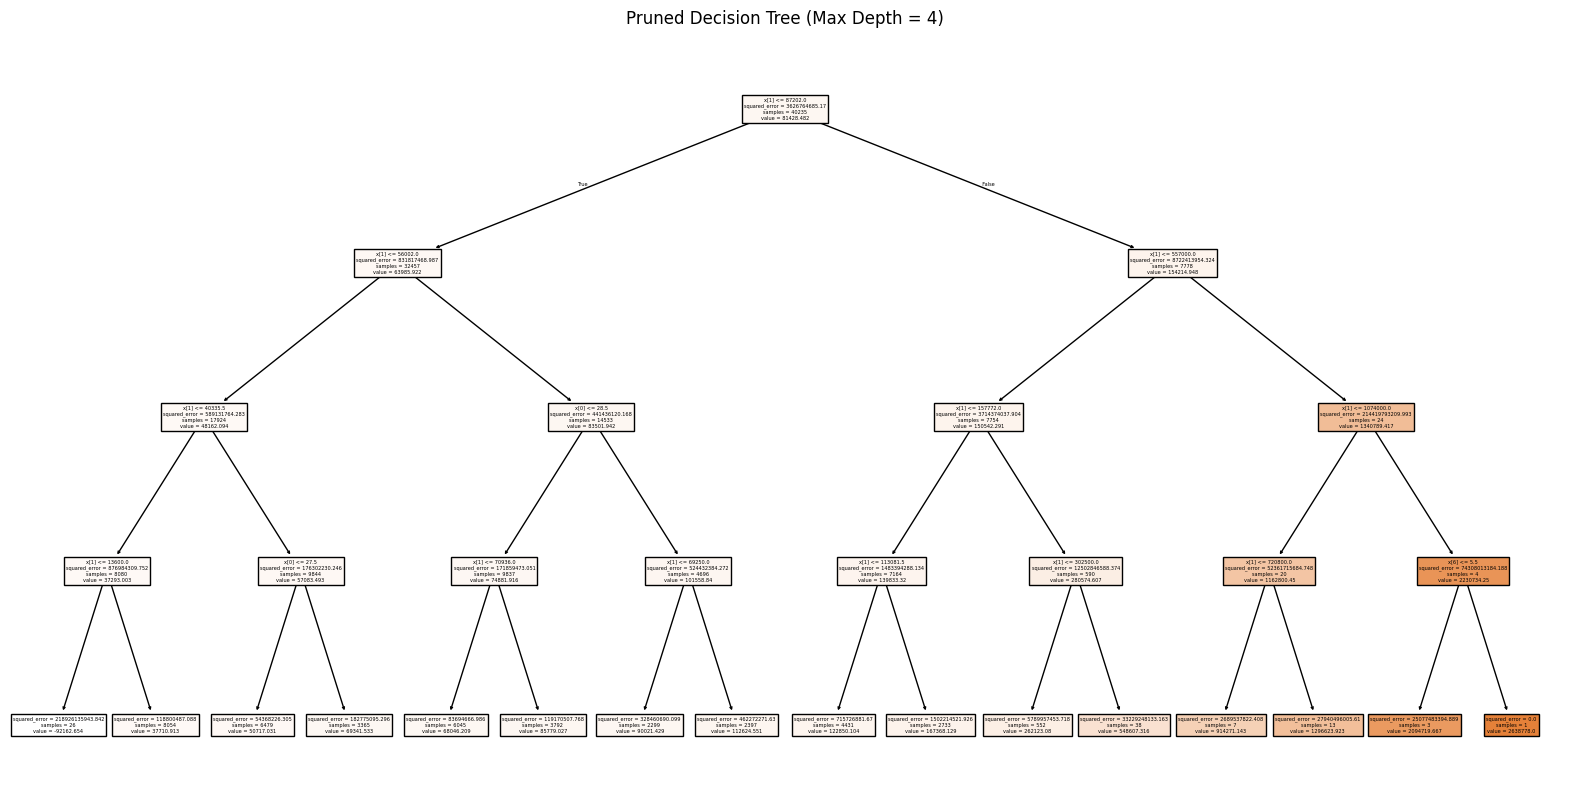

In [ ]:
# Plot ONLY pruned tree (recommended for coursework)
plt.figure(figsize=(20,10))
plot_tree(dt_pruned, filled=True, max_depth=4)
plt.title("Pruned Decision Tree (Max Depth = 4)")
plt.show()

Section 20 - Predicting Max Allowed Loan for the Client

In [ ]:
# Reconstruct Client 60256 as a raw one-row DataFrame
client_raw_data = pd.DataFrame([{
    'age': 56,
    'income': 57000,
    'emplyment_length': 15,
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'credit_history_length': 35,
    'home_ownership_OTHER': 0,
    'home_ownership_OWN': 0,
    'home_ownership_RENT': 1,
    'loan_intent_EDUCATION': 0,
    'loan_intent_HOMEIMPROVEMENT': 0,
    'loan_intent_MEDICAL': 1,
    'loan_intent_PERSONAL': 0,
    'loan_intent_VENTURE': 0,
    'payment_default_on_file_Y': 0
}])

# Reorder columns to match the regression training data
client_raw_data = client_raw_data[X_train.columns]

# Predict the maximum loan amount using DT-2
predicted_max_loan = dt_pruned.predict(client_raw_data)

# Display the prediction
print(f"The Predicted Maximum Loan Amount for Client 60256 is: £{predicted_max_loan[0]:.2f}")

The Predicted Maximum Loan Amount for Client 60256 is: £90021.43
